In [81]:
from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
from matplotlib import pyplot as plt

DATA_DIR = Path('../../data')

%config InlineBackend.figure_format = 'retina'

In [ ]:


df = pd.read_csv(DATA_DIR / 'results/06_proteinqc_jain_shehata_antibodies/descriptors.csv')
df['design_id'] = df.design_id.str.slice(4)  # remove the pool identifier from the design_id
df = df.set_index('design_id')
df

In [2]:
shehata_descriptors = df.iloc[:400]
jain_descriptors = df.iloc[400:]

In [8]:
def load_shehata_assays():
    shehata = pd.read_excel(DATA_DIR / 'jain_shehata/assays/1-s2.0-S2211124719311040-mmc2.xlsx', index_col=0).iloc[:-2]
    assays = shehata.iloc[:, 1:4]
    # set ND to NaN
    assays = assays.replace('ND', np.nan)
    assays = assays.replace('Did not elute', np.nan)  # one occurrence, skipping
    # convert to numeric
    assays = assays.apply(pd.to_numeric)
    return assays

def load_jain_assays():
    assays = pd.read_excel(DATA_DIR / 'jain_shehata/assays/pnas.1616408114.sd03.xlsx').iloc[:-2]  # Remove last two rows which are not part of the data
    assays = assays.set_index('Name')
    return assays


In [9]:
# First download assay results:
# Jain https://www.pnas.org/doi/suppl/10.1073/pnas.1616408114/suppl_file/pnas.1616408114.sd03.xlsx, https://doi.org/10.1073/pnas.1616408114
# Shehata https://ars.els-cdn.com/content/image/1-s2.0-S2211124719311040-mmc2.xlsx, https://doi.org/10.1016/j.celrep.2019.08.056
# And place them under <repo_root>/data/jain_shehata/assays/

In [10]:
shehata_assays = load_shehata_assays()
shehata_assays

/var/folders/3l/jgr64hdj3jqd5hnjydjqt1y00000gn/T/ipykernel_81188/1937192914.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  assays = assays.replace('ND', np.nan)
/var/folders/3l/jgr64hdj3jqd5hnjydjqt1y00000gn/T/ipykernel_81188/1937192914.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  assays = assays.replace('Did not elute', np.nan)  # one occurrence, skipping


,TmApp (°C),PSR Score,HIC retention time (min)
Clone name,,,
ADI-38502,66.0,0.000000,8.886
ADI-38501,64.5,0.023184,8.959
ADI-47173,64.5,0.000000,8.465
ADI-47054,71.0,0.011716,8.523
ADI-47278,71.5,0.010336,8.547
...,...,...,...
ADI-47245,NaN,0.000000,9.760
ADI-45475,NaN,0.000000,NaN
ADI-47271,NaN,0.071894,NaN


In [11]:
jain_assays = load_jain_assays()
jain_assays

,HEK Titer (mg/L),Fab Tm by DSF (°C),SGAC-SINS AS100 ((NH4)2SO4 mM),HIC Retention Time (Min)a,SMAC Retention Time (Min)a,Slope for Accelerated Stability,Poly-Specificity Reagent (PSR) SMP Score (0-1),Affinity-Capture Self-Interaction Nanoparticle Spectroscopy (AC-SINS) ∆λmax (nm) Average,CIC Retention Time (Min),CSI-BLI Delta Response (nm),ELISA,BVP ELISA
Name,,,,,,,,,,,,
abituzumab,89.555458,75.5,900.0,9.227,8.725,0.05563,0.166666,1.458861,8.621,0.00,1.137375,2.720799
abrilumab,100.223196,71.0,900.0,9.413,8.699,0.02829,0.000000,-0.928526,8.384,-0.02,1.124624,1.818303
adalimumab,134.928638,71.0,900.0,8.816,8.672,0.05069,0.000000,1.062328,8.865,-0.01,1.075515,1.488186
alemtuzumab,144.653543,74.5,1000.0,8.769,8.672,0.06431,0.000000,-0.789199,8.514,-0.02,1.161491,1.464226
alirocumab,69.232345,71.5,900.0,9.036,8.681,0.02920,0.000000,1.230511,8.757,-0.01,1.196224,2.179700
...,...,...,...,...,...,...,...,...,...,...,...,...
vedolizumab,221.762037,80.5,600.0,10.942,12.307,0.06906,0.000000,0.388178,8.986,-0.02,1.152671,1.584027
veltuzumab,224.953517,70.0,700.0,11.092,9.725,0.03990,0.000000,4.831871,8.792,-0.02,0.888809,1.211236
visilizumab,242.006377,71.0,0.0,9.007,8.695,0.05760,0.418071,21.988193,9.146,0.01,1.880772,4.799334


In [12]:
def correlate_all_vs_all(descriptors, assays):
    # assert no NaNs in descriptors
    assert not descriptors.isnull().values.any()

    correlations = {}

    for assay_col in assays.columns:
        for col in descriptors.columns:
            # Calculate Spearman correlation
            corr, _ = spearmanr(descriptors[col], assays[assay_col].loc[descriptors.index], nan_policy='omit')
            correlations[(col, assay_col)] = corr

    # Create a DataFrame from the correlations
    correlation_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Spearman Correlation'])
    correlation_df = correlation_df.sort_values(by='Spearman Correlation',  ascending=False)
    correlation_df.index = pd.MultiIndex.from_tuples(correlation_df.index, names=['Descriptor', 'Assay'])
    correlation_df = correlation_df.reset_index()
    correlation_df['Abs Spearman Correlation'] = correlation_df['Spearman Correlation'].abs()
    return correlation_df

In [13]:
def show_top_correlations(correlation_df, n=2, sort_by_corr=False):
    # Show top n correlations for each assay
    correlation_df = correlation_df.sort_values(by=['Assay', 'Abs Spearman Correlation'], ascending=[True, False])
    top_correlations = correlation_df.groupby('Assay', sort=False).head(n)
    top_correlations = top_correlations.reset_index(drop=True)
    
    # display Spearman correlation with two decimals and color the cells based on correlation value
    if sort_by_corr:
        top_correlations = top_correlations.sort_values(by='Abs Spearman Correlation', ascending=False).reset_index(drop=True)
    return top_correlations.style.format({
        'Spearman Correlation': '{:.2f}',
        'Abs Spearman Correlation': '{:.2f}',
    }).background_gradient(cmap='coolwarm', vmin=0, vmax=1, subset=['Abs Spearman Correlation'])

In [14]:
shehata_corr = correlate_all_vs_all(shehata_descriptors, shehata_assays)
show_top_correlations(shehata_corr)

,Descriptor,Assay,Spearman Correlation,Abs Spearman Correlation
0,Hydrophobic SAP score,HIC retention time (min),0.49,0.49
1,Hydrophobicity potential,HIC retention time (min),0.48,0.48
2,Positive electrostatic regions volume integral at pH 7.4,PSR Score,0.24,0.24
3,Positive electrostatic volume integral at pH 7.4,PSR Score,0.24,0.24
4,Negative electrostatic regions volume integral at pH 5.5,TmApp (°C),0.24,0.24
5,Negative electrostatic volume integral at pH 5.5,TmApp (°C),0.24,0.24


In [15]:
jain_corr = correlate_all_vs_all(jain_descriptors, jain_assays)
show_top_correlations(jain_corr, sort_by_corr=True)

,Descriptor,Assay,Spearman Correlation,Abs Spearman Correlation
0,Hydrophobic SAP score,SMAC Retention Time (Min)a,0.59,0.59
1,Hydrophobic SAP score,HIC Retention Time (Min)a,0.58,0.58
2,Hydrophobicity potential,HIC Retention Time (Min)a,0.57,0.57
3,Hydrophobicity potential,SMAC Retention Time (Min)a,0.56,0.56
4,Hydrophobic SAP score,CIC Retention Time (Min),0.42,0.42
5,Hydrophobicity potential,CIC Retention Time (Min),0.41,0.41
6,Hydrophobicity potential,SGAC-SINS AS100 ((NH4)2SO4 mM),-0.40,0.40
7,Hydrophobic SAP score,SGAC-SINS AS100 ((NH4)2SO4 mM),-0.39,0.39
8,Positive electrostatic regions volume integral at pH 5.5,Poly-Specificity Reagent (PSR) SMP Score (0-1),0.38,0.38
9,Positive electrostatic volume integral at pH 7.4,Poly-Specificity Reagent (PSR) SMP Score (0-1),0.37,0.37


In [16]:
# Caution, some Shehata assays contain NaNs (out of 400 mAbs)
shehata_assays.isna().sum()

TmApp (°C)                  54
PSR Score                    2
HIC retention time (min)    52
dtype: int64

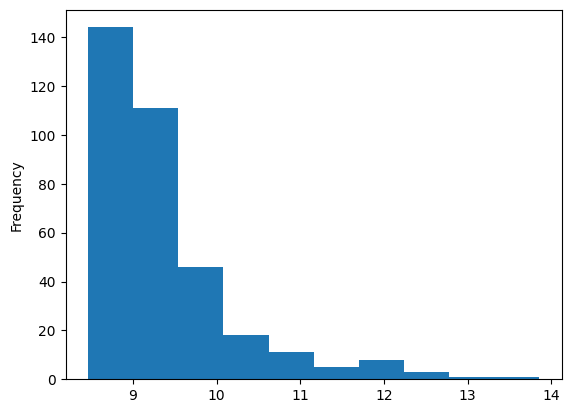

In [20]:
shehata_hic = shehata_assays['HIC retention time (min)'].dropna()
shehata_hic.plot.hist();

In [24]:
shehata_corr[shehata_corr['Assay'] == 'HIC retention time (min)'].sort_values('Abs Spearman Correlation', ascending=False).head()

,Descriptor,Assay,Spearman Correlation,Abs Spearman Correlation
0,Hydrophobic SAP score,HIC retention time (min),0.486148,0.486148
1,Hydrophobicity potential,HIC retention time (min),0.484839,0.484839
2,Hydrophobic patch area,HIC retention time (min),0.334744,0.334744
3,Normalized hydrophobic patch area,HIC retention time (min),0.314207,0.314207
14,Hydrophobic top1 patch area,HIC retention time (min),0.208709,0.208709


In [30]:
shehata_hic_area = shehata_descriptors['Normalized hydrophobic patch area'].loc[shehata_hic.index]
shehata_hic_area.head()

Clone name
ADI-38502    0.197999
ADI-38501    0.170814
ADI-47173    0.150919
ADI-47054    0.128166
ADI-47278    0.138153
Name: Normalized hydrophobic patch area, dtype: float64

In [26]:
shehata_hic_sap = shehata_descriptors['Hydrophobic SAP score'].loc[shehata_hic.index]
shehata_hic_sap.head()

Clone name
ADI-38502    756.173585
ADI-38501    676.690120
ADI-47173    584.512512
ADI-47054    561.406164
ADI-47278    460.482233
Name: Hydrophobic SAP score, dtype: float64

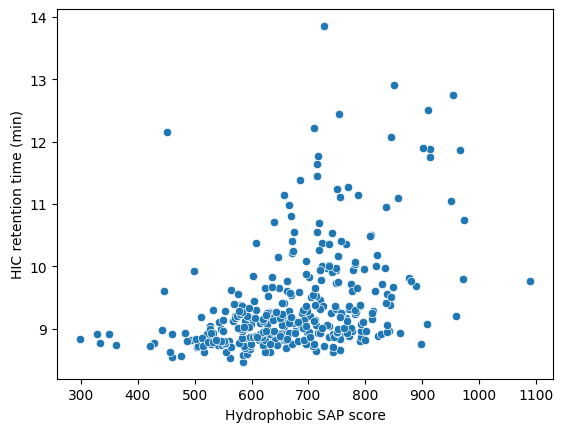

In [28]:
sns.scatterplot(x=shehata_hic_sap, y=shehata_hic);

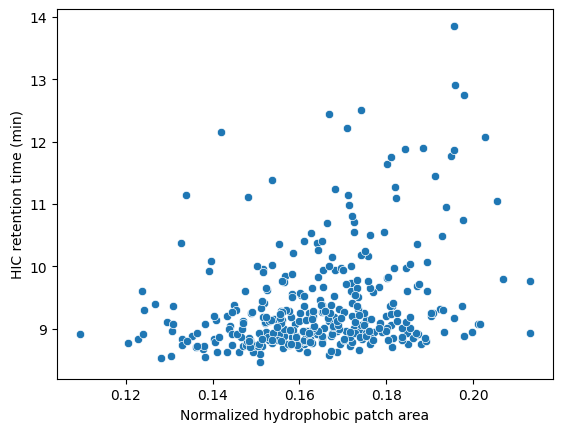

In [41]:
sns.scatterplot(x=shehata_hic_area, y=shehata_hic);

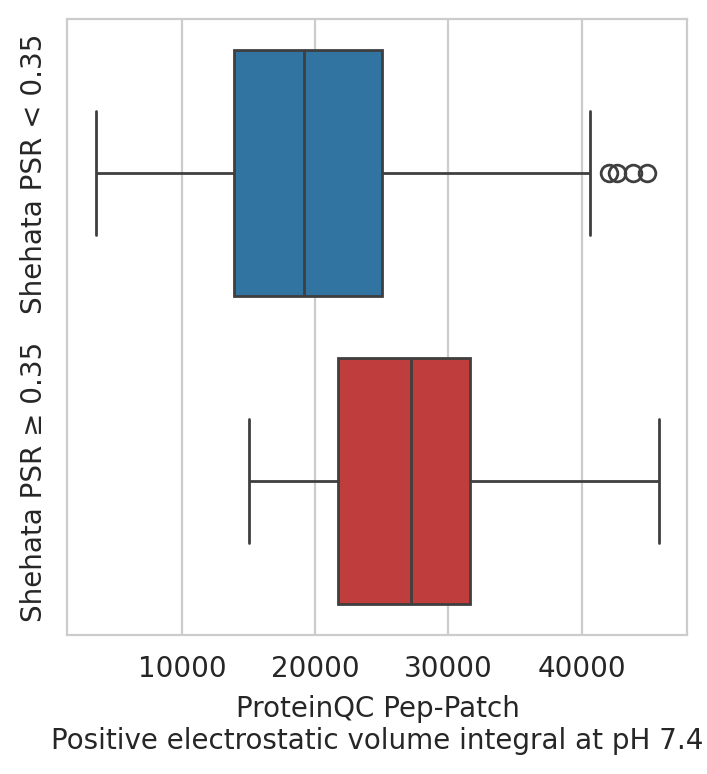

In [103]:
with sns.axes_style('whitegrid'):
    threshold = '0.35'
    y = (shehata_assays['PSR Score'] >= float(threshold)).replace({True: f'Shehata PSR ≥ {threshold}', False: f'Shehata PSR < {threshold}'})
    x = shehata_descriptors['Positive electrostatic volume integral at pH 7.4']
    fig, ax = plt.subplots(figsize=(4, 4))
    ax = sns.boxplot(
        x=x,
        y=y, 
        palette={f'Shehata PSR ≥ {threshold}': 'tab:red', f'Shehata PSR < {threshold}': 'tab:blue'},
        legend=False,
        hue=y,
    );
    ax.set_ylabel('');
    ax.set_xlabel(f'ProteinQC Pep-Patch\n{x.name}');
    ax.set_yticks(ax.get_yticks());
    ax.set_yticklabels(ax.get_yticklabels(), rotation=90, va='center');

In [42]:
jain_corr[jain_corr['Assay'] == 'HIC Retention Time (Min)a'].sort_values('Abs Spearman Correlation', ascending=False).head()

,Descriptor,Assay,Spearman Correlation,Abs Spearman Correlation
1,Hydrophobic SAP score,HIC Retention Time (Min)a,0.579024,0.579024
2,Hydrophobicity potential,HIC Retention Time (Min)a,0.573370,0.573370
5,Hydrophobic patch area,HIC Retention Time (Min)a,0.509207,0.509207
7,Normalized hydrophobic patch area,HIC Retention Time (Min)a,0.472858,0.472858
8,Hydrophobic top1 patch area,HIC Retention Time (Min)a,0.466200,0.466200


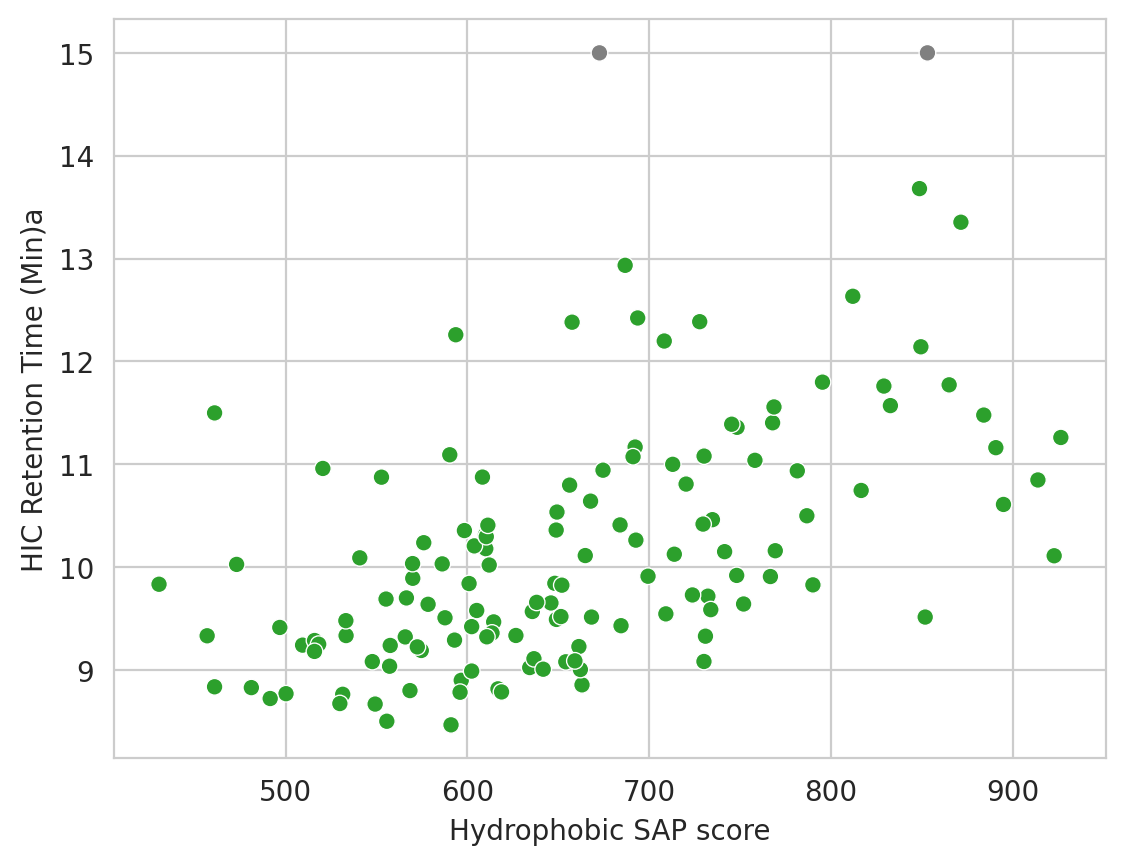

In [113]:
with sns.axes_style('whitegrid'):
    sns.scatterplot(
        x=jain_descriptors['Hydrophobic SAP score'], 
        y=jain_assays['HIC Retention Time (Min)a'].replace({25.0: 15}),
        hue=jain_assays['HIC Retention Time (Min)a'] == 25.0,
        palette={True: 'grey', False: 'tab:green'},
        legend=False
    );

dinutuximab sirukumab
ADI-47088 ADI-45499


/var/folders/3l/jgr64hdj3jqd5hnjydjqt1y00000gn/T/ipykernel_81188/3325171495.py:39: UserWarning: Glyph 9076 (\N{APL FUNCTIONAL SYMBOL RHO}) missing from font(s) Arial.
  fig.tight_layout(h_pad=5)


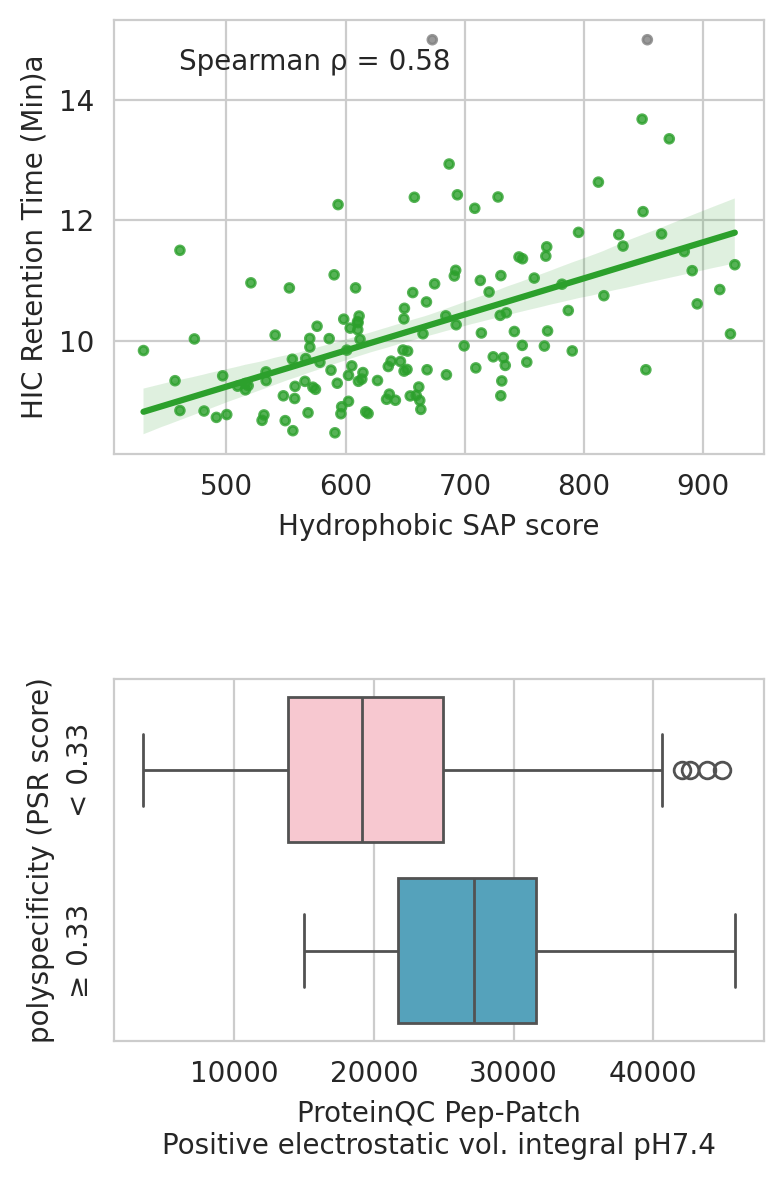

In [159]:
with sns.axes_style('whitegrid'):
    fig, axes = plt.subplots(2, 1, figsize=(4, 6), height_ratios=(1.2, 1))
    x = jain_descriptors['Hydrophobic SAP score']
    y = jain_assays['HIC Retention Time (Min)a']
    ax = sns.regplot(
        x=x, 
        y=y.replace({25.0: 15}),
        #hue=jain_assays['HIC Retention Time (Min)a'] == 25.0,
        #palette={True: 'grey', False: 'tab:green'},
        #legend=False,
        color='tab:green',
        scatter_kws=dict(
            s=10,
            color=['grey' if v == 25.0 else 'tab:green' for v in y],
        ),
        ax=axes[0],
    );
    ax.text(460, 14.5, f'Spearman ⍴ = {spearmanr(x, y)[0]:.2f}')
    print(x.idxmin(), x.idxmax())

    threshold = '0.33'
    y = (shehata_assays['PSR Score'] >= float(threshold)).replace({True: f'≥ {threshold}', False: f'< {threshold}'})
    x = shehata_descriptors['Positive electrostatic volume integral at pH 7.4'].rename(
        'Positive electrostatic vol. integral pH7.4'
    )
    ax = sns.boxplot(
        x=x,
        y=y, 
        palette={f'≥ {threshold}': '#44aacc', f'< {threshold}': 'pink'},
        legend=False,
        hue=y,
        ax=axes[1],
    );
    print(x.idxmin(), x.idxmax())
    ax.set_ylabel('polyspecificity (PSR score)');
    ax.set_xlabel(f'ProteinQC Pep-Patch\n{x.name}');
    ax.set_yticks(ax.get_yticks());
    ax.set_yticklabels(ax.get_yticklabels(), rotation=90, va='center');
    fig.tight_layout(h_pad=5)

In [160]:
jain_descriptors['Hydrophobic SAP score'].sort_values()

design_id
dinutuximab     430.432280
palivizumab     456.902688
codrituzumab    460.985521
bavituximab     460.993645
fasinumab       473.111465
                   ...    
urelumab        890.693111
olaratumab      894.885202
tabalumab       913.825459
cetuximab       922.768984
sirukumab       926.439367
Name: Hydrophobic SAP score, Length: 137, dtype: float64

In [161]:
shehata_descriptors['Positive electrostatic volume integral at pH 7.4'].sort_values()

design_id
ADI-47088     3519.481247
ADI-47153     3676.950841
ADI-47089     4055.220279
ADI-47122     4187.824535
ADI-45451     4946.868813
                 ...     
ADI-47311    42027.327748
ADI-37123    42630.009758
ADI-47292    43876.037647
ADI-47300    44893.694143
ADI-45499    45830.319517
Name: Positive electrostatic volume integral at pH 7.4, Length: 400, dtype: float64